In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Ethiopia

In [34]:
df = pd.read_csv("../data/ethiopia.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [8]:
df["Country"] = "Ethiopia"

df["DATE"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df["MONTH"] = df["DATE"].dt.month

In [9]:
df = df.replace(-999, np.nan) 

In [10]:
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [13]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
MONTH          0.0
dtype: float64

In [14]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z = df[cols].apply(zscore)
outliers = (np.abs(z) > 3).sum()
outliers

T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64

In [21]:
df.ffill(inplace=True)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,MONTH
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3


In [16]:
df = df.dropna(thresh=len(df.columns)*0.7)

In [30]:
df.to_csv("../data/ethiopia_clean.csv", index=False)
df.to_csv("../data/kenya_clean.csv", index=False)
df.to_csv("../data/tanzania_clean.csv", index=False)
df.to_csv("../data/rwanda_clean.csv", index=False)
df.to_csv("../data/nigeria_clean.csv", index=False)
df.to_csv("../data/sudan_clean.csv", index=False)

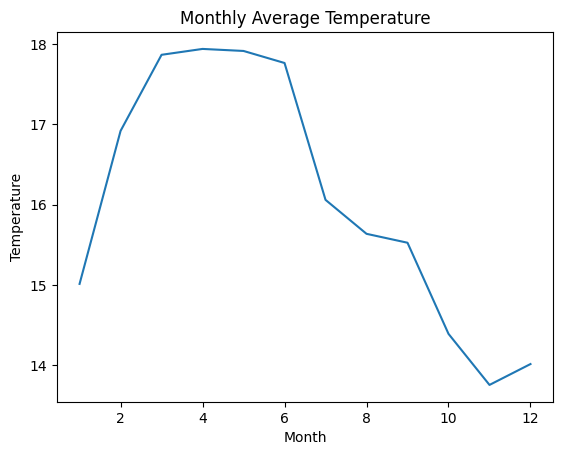

In [19]:
monthly_temp = df.groupby("MONTH")["T2M"].mean()

plt.figure()
monthly_temp.plot()
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

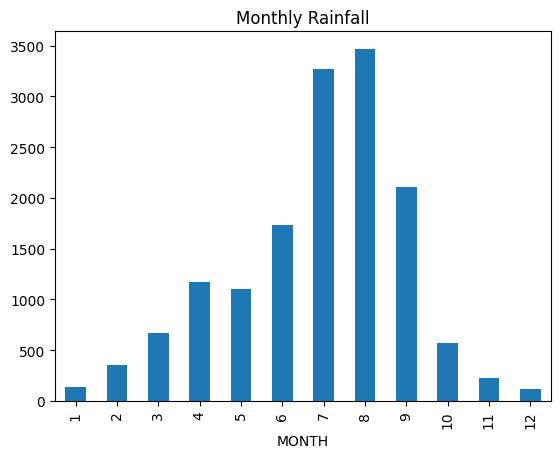

In [20]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].sum()

plt.figure()
monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

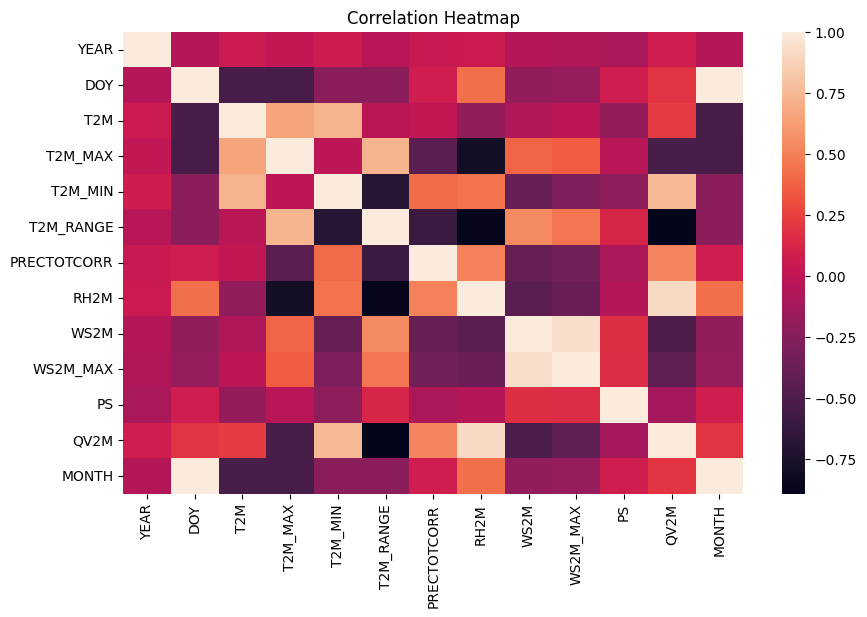

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True))
plt.title("Correlation Heatmap")
plt.show()

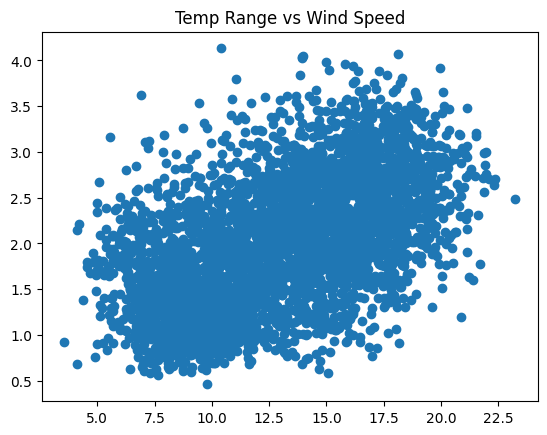

In [23]:
plt.figure()
plt.scatter(df["T2M_MAX"] - df["T2M_MIN"], df["WS2M"])
plt.title("Temp Range vs Wind Speed")
plt.show()

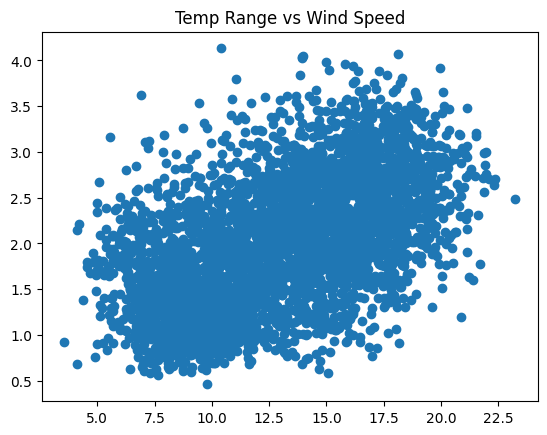

In [24]:
plt.figure()
plt.scatter(df["T2M_MAX"] - df["T2M_MIN"], df["WS2M"])
plt.title("Temp Range vs Wind Speed")
plt.show()

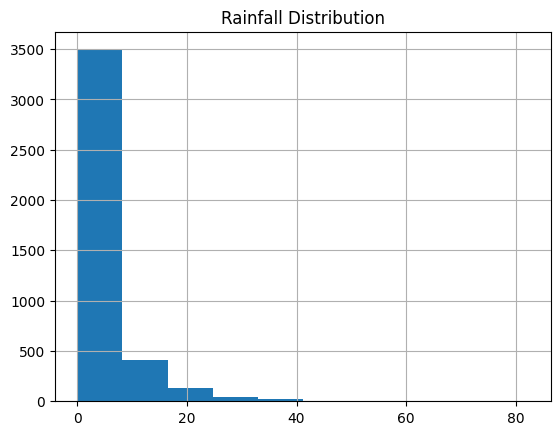

In [25]:
plt.figure()
df["PRECTOTCORR"].hist()
plt.title("Rainfall Distribution")
plt.show()

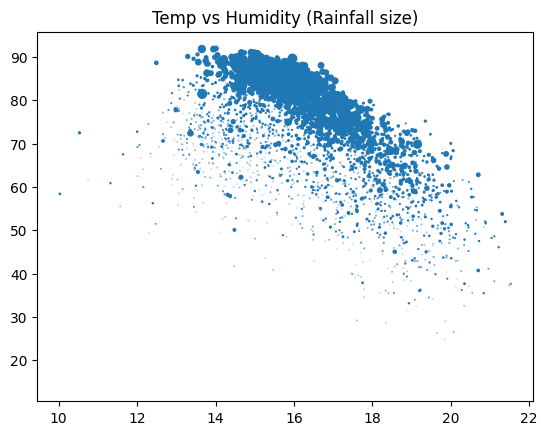

In [ ]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"])
plt.title("Temp vs Humidity (Rainfall size)")
plt.show()


In [ ]:
#kenya

In [35]:
df = pd.read_csv("../data/kenya.csv")
df["Country"] = "Kenya"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["MONTH"] = df["DATE"].dt.month
df = df.replace(-999, np.nan)
df = df.drop_duplicates()
df = df.ffill()

In [ ]:
#nigeria

In [ ]:
df = pd.read_csv("../data/nigeria.csv")
df["Country"] = "Nigeria"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["MONTH"] = df["DATE"].dt.month
df = df.replace(-999, np.nan)
df = df.drop_duplicates()
df = df.ffill()

In [ ]:
#sudan

In [ ]:
df = pd.read_csv("../data/sudan.csv")
df["Country"] = "Sudan"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["MONTH"] = df["DATE"].dt.month
df = df.replace(-999, np.nan)
df = df.drop_duplicates()
df = df.ffill()

In [ ]:
#tanzania

In [ ]:
df = pd.read_csv("../data/tanzania.csv")
df["Country"] = "Tanzania"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["MONTH"] = df["DATE"].dt.month
df = df.replace(-999, np.nan)
df = df.drop_duplicates()
df = df.ffill()